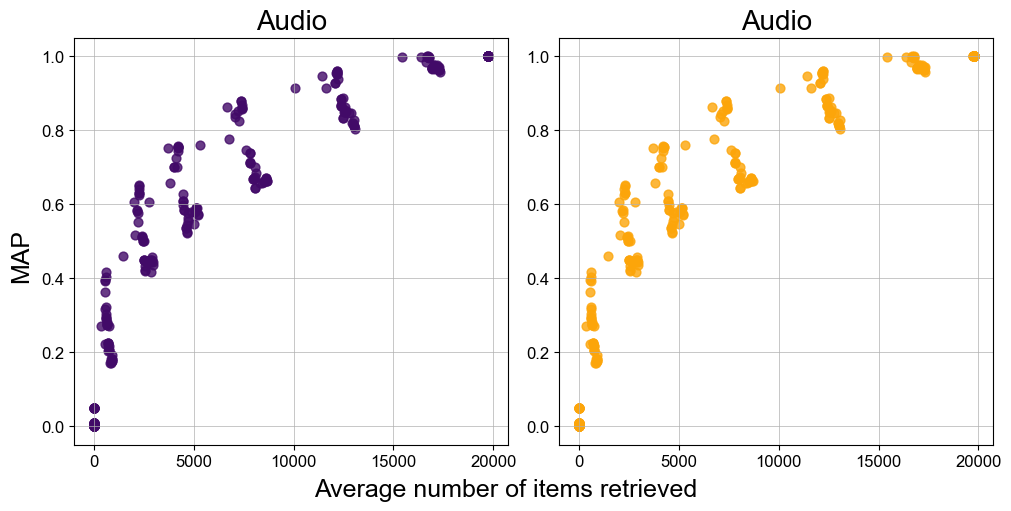

In [1]:
import pickle
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager

font = font_manager.FontEntry(fname="arial.ttf", name="Arial")
font_manager.fontManager.ttflist.append(font)

mpl.rcParams['font.family'] = "Arial"


plot_markersize = 10
opas_markersize = 250
opas_idmarkersize = 200
axis_fontsize = 18
title_fontsize = 20
label_fontsize = 12

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, constrained_layout=True)
fig.supxlabel("Average number of items retrieved", fontsize=axis_fontsize)
fig.supylabel("MAP", fontsize=axis_fontsize)
colors = plt.cm.inferno(np.linspace(0.2, 0.8, 2))

for d, dataset in enumerate(["audio", "audio"]):
    with open(f"data/lsh_multi_final_{dataset}.pkl", "rb") as f:
        lss = pickle.load(f)

    for i, ls in enumerate(lss):
        info = ls[:3]
        ls = ls[3:]
        MAP = ls[::3]
        avg_items = ls[1::3]
        avg_relevant = ls[2::3]
        kbits = [10, 8, 7, 6, 5, 4, 2, 1]
        if i == 0:
            ax[d].scatter(avg_items, MAP, s=40, alpha=0.8, color=colors[d], label=f"{dataset.capitalize()}")
        else:
            ax[d].scatter(avg_items, MAP, s=40, alpha=0.8, color=colors[d])
        ax[d].tick_params(axis='both', which='major', labelsize=label_fontsize)
        ax[d].set_title(f"{dataset.capitalize()}", fontsize=title_fontsize)
        ax[d].grid(linewidth=0.5)

# legend = fig.legend(loc='upper center', ncol=2, fontsize=15)
# coords = legend.get_window_extent().get_points()[0]
# fig.legends = []
# scale = fig.get_window_extent().get_points()[1]
# fig.legend(bbox_to_anchor=(coords[0]/scale[0], coords[1]/scale[1]+0.2), loc=2, ncol=2, fontsize=15)
# fig.savefig('map_vs_num_retrieved_lsh.pdf', bbox_inches='tight')
plt.show()